In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
DATA_PATH = os.path.join("..", "data", "raw", "online_retail.csv")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
print("Raw shape:", df.shape)

df = df.dropna(subset=["Customer ID"])
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["Price"]

print("Cleaned shape:", df.shape)
df.head()

Raw shape: (1067371, 8)
Cleaned shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
reference_date = df["InvoiceDate"].max() + timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum"),
).reset_index()

print(f"Number of unique customers: {len(rfm)}")
rfm[["Recency", "Frequency", "Monetary"]].describe()

Number of unique customers: 5878


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


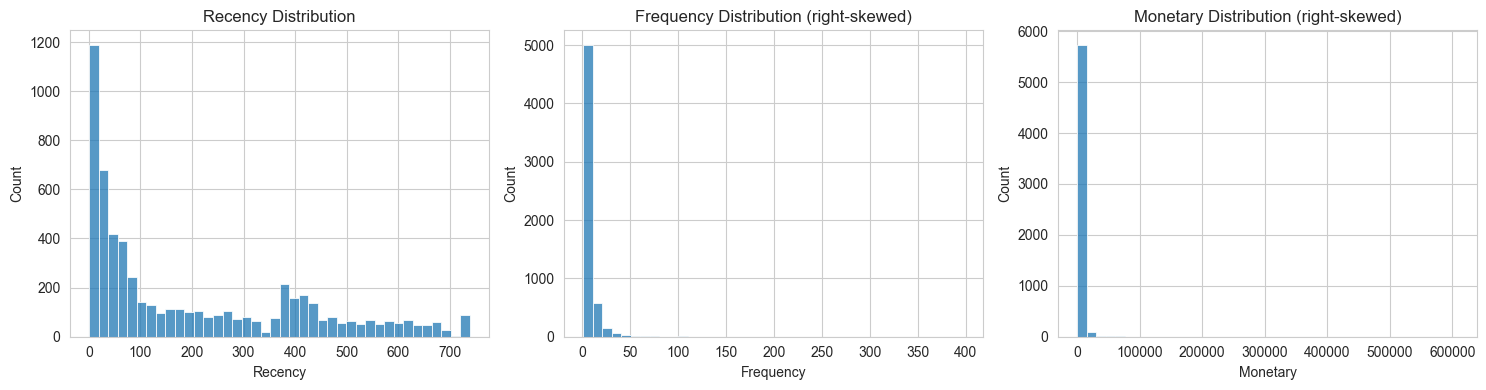

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=40, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=40, ax=axes[1])
axes[1].set_title("Frequency Distribution (right-skewed)")

sns.histplot(rfm["Monetary"], bins=40, ax=axes[2])
axes[2].set_title("Monetary Distribution (right-skewed)")

plt.tight_layout()
plt.show()

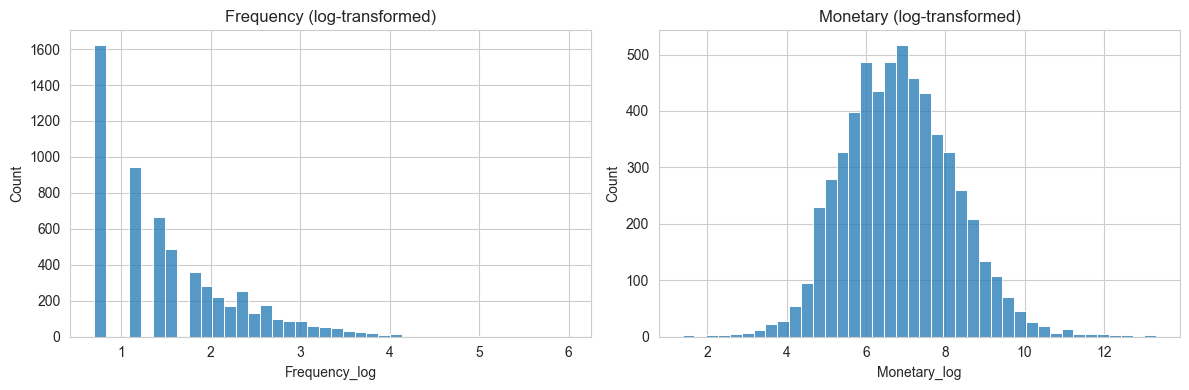

Features scaled and ready for clustering.


In [5]:
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(rfm["Frequency_log"], bins=40, ax=axes[0])
axes[0].set_title("Frequency (log-transformed)")
sns.histplot(rfm["Monetary_log"], bins=40, ax=axes[1])
axes[1].set_title("Monetary (log-transformed)")
plt.tight_layout()
plt.show()

features = rfm[["Recency", "Frequency_log", "Monetary_log"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("Features scaled and ready for clustering.")

k=2: silhouette score = 0.4186
k=3: silhouette score = 0.4010
k=4: silhouette score = 0.3614
k=5: silhouette score = 0.3665
k=6: silhouette score = 0.3499


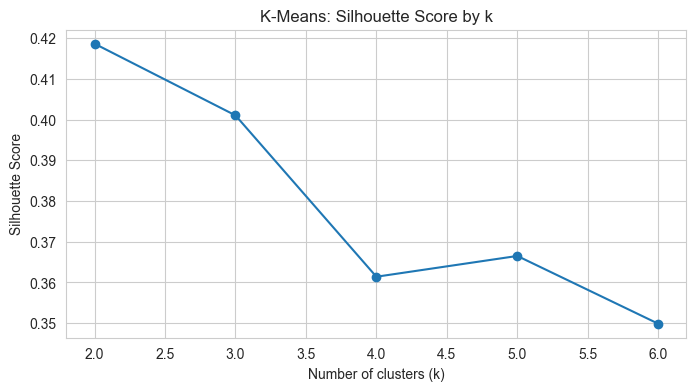


Best k=2, silhouette score=0.4186


In [6]:
silhouette_scores = []
models = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)
    models[k] = kmeans
    print(f"k={k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 7), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means: Silhouette Score by k")
plt.show()

best_k = list(models.keys())[np.argmax(silhouette_scores)]
best_kmeans_model = models[best_k]
best_score = max(silhouette_scores)
print(f"\nBest k={best_k}, silhouette score={best_score:.4f}")

In [7]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_features)

num_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN found {num_clusters_dbscan} clusters, {num_noise} noise points")

rfm["DBSCAN_Cluster"] = dbscan_labels

DBSCAN found 2 clusters, 69 noise points


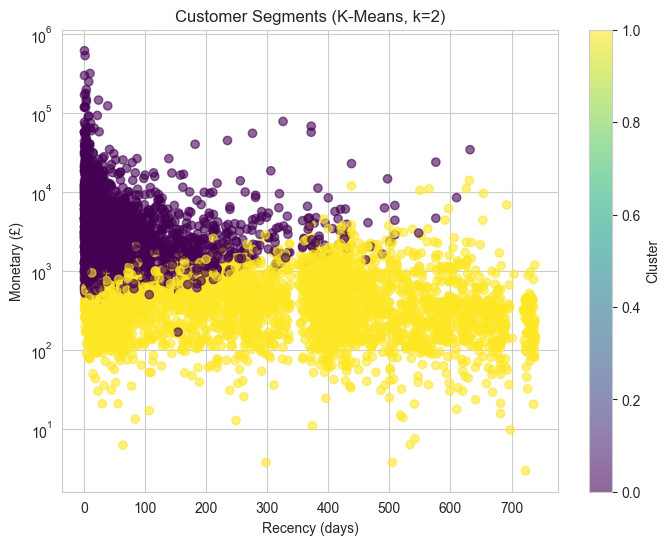

In [ ]:
rfm["KMeans_Cluster"] = best_kmeans_model.predict(scaled_features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    rfm["Recency"], rfm["Monetary"],
    c=rfm["KMeans_Cluster"], cmap="viridis", alpha=0.6
)
plt.xlabel("Recency (days)")
plt.ylabel("Monetary (£)")
plt.yscale("log")  
plt.title(f"Customer Segments (K-Means, k={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [9]:
segment_summary = rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
segment_summary["customer_count"] = rfm.groupby("KMeans_Cluster").size()
print(segment_summary)

                Recency  Frequency  Monetary  customer_count
KMeans_Cluster                                              
0                  63.1       11.6    5987.7            2674
1                 316.7        1.9     540.6            3204


In [10]:
model_bundle = {
    "kmeans_model": best_kmeans_model,
    "scaler": scaler,
    "best_k": best_k,
    "silhouette_score": best_score,
}
save_path = os.path.join(MODEL_DIR, "segmentation_model.pkl")
joblib.dump(model_bundle, save_path)
print(f"Saved segmentation model to {save_path}")

rfm_output_path = os.path.join("..", "data", "customer_segments.csv")
rfm.to_csv(rfm_output_path, index=False)
print(f"Saved customer segments to {rfm_output_path}")

Saved segmentation model to ..\models\segmentation_model.pkl
Saved customer segments to ..\data\customer_segments.csv
